<a href="https://colab.research.google.com/github/tsholofelo-mokheleli/ACIS-2023-New-Zealand/blob/main/triage%20data%20cleaning%20and%20feature%20engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SRB Triage - Data Cleaning | Data Preprocessing | EDA**

### **Import Libraries**

In [481]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from google.colab import files

warnings.filterwarnings('ignore')

In [482]:
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.titlesize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})
sns.set_style("white")

export_pdf = True

out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)

def safe_name(s: str) -> str:
    return "".join(c if (c.isalnum() or c in "-_") else "_" for c in s).strip("_")

### **Load the dataset**

In [483]:
df = pd.read_csv('bq-results-20260511.csv')

### **Data Inspection**

In [484]:
df.shape

(202990, 49)

In [485]:
df.rename(columns={"chiefcomplaint_clean": "chiefcomplaint"}, inplace=True)
df.rename(columns={"race_descriptive_only": "race"}, inplace=True)

In [486]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202990 entries, 0 to 202989
Data columns (total 49 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   subject_id                              202990 non-null  int64  
 1   hadm_id                                 202990 non-null  int64  
 2   stay_id                                 202990 non-null  int64  
 3   triage_time                             202990 non-null  object 
 4   chiefcomplaint                          202982 non-null  object 
 5   gender                                  202990 non-null  object 
 6   age                                     202990 non-null  int64  
 7   temperature                             185679 non-null  float64
 8   heartrate                               189575 non-null  float64
 9   resprate                                187581 non-null  float64
 10  o2sat                                   1875

In [487]:
df.head()

,subject_id,hadm_id,stay_id,triage_time,chiefcomplaint,gender,age,temperature,heartrate,resprate,...,hist_sud,hist_mood,hist_anxiety,hist_srb,hist_ptsd,hist_psychotic_disorder,hist_chronic_pain,hist_cancer,prior_admission_count,srb_outcome
0,15350437,20383396,39042378,2110-01-11 03:43:00,"diplopia, transfer",M,34,97.1,71.0,16.0,...,0,0,0,0,0,0,0,0,0,0
1,17195991,23542772,38649090,2110-01-11 21:42:00,trigger to rm 20,F,61,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,16077914,26110624,33855940,2110-01-12 02:01:00,si,F,25,98.5,95.0,20.0,...,0,0,0,0,0,0,0,0,0,0
3,18663120,27446848,38637075,2110-01-13 12:17:00,si,F,30,97.2,80.0,19.0,...,0,0,0,0,0,0,0,0,0,0
4,17288055,27318631,35742023,2110-01-13 13:12:00,pregnant,F,32,97.0,99.0,18.0,...,0,0,0,0,0,0,0,0,0,0


In [488]:
df.describe().round(2)

,subject_id,hadm_id,stay_id,age,temperature,heartrate,resprate,o2sat,sbp,dbp,...,hist_sud,hist_mood,hist_anxiety,hist_srb,hist_ptsd,hist_psychotic_disorder,hist_chronic_pain,hist_cancer,prior_admission_count,srb_outcome
count,202990.00,202990.00,202990.00,202990.00,185679.00,189575.00,187581.00,187580.00,189148.00,188711.00,...,202990.00,202990.00,202990.00,202990.00,202990.00,202990.00,202990.00,202990.00,202990.00,202990.00
mean,15011679.70,24994989.07,35002897.84,59.99,98.07,86.43,17.88,98.02,134.81,78.70,...,0.21,0.16,0.17,0.03,0.04,0.04,0.13,0.11,4.37,0.02
std,2875658.68,2888734.39,2887198.33,19.54,4.02,19.37,6.53,23.45,62.16,251.81,...,0.40,0.36,0.38,0.16,0.19,0.19,0.34,0.32,10.49,0.13
min,10000032.00,20000019.00,30000012.00,18.00,0.10,1.00,1.00,0.00,1.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,12515925.25,22489808.50,32501034.00,47.00,97.60,73.00,16.00,97.00,118.00,66.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,15017942.00,24999394.00,35005260.50,61.00,98.00,85.00,18.00,98.00,133.00,76.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
75%,17506366.50,27493895.75,37501300.00,75.00,98.60,98.00,18.00,100.00,149.00,86.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,0.00
max,19999987.00,29999809.00,39999965.00,103.00,978.00,1228.00,1820.00,9322.00,19734.00,74810.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,237.00,1.00


In [489]:
unique_ids = df['subject_id'].nunique()
print(unique_ids)

107373


### **Check target distributions**

In [490]:
# Class distribution
print(df['srb_outcome'].value_counts())
print("\n========================================\n")
print(df['srb_outcome'].value_counts(normalize=True) * 100)

srb_outcome
0    199604
1      3386
Name: count, dtype: int64


srb_outcome
0    98.331938
1     1.668062
Name: proportion, dtype: float64


### **Exploring and Imputing missing Data**

In [491]:
missing_count = df.isnull().sum()
missing_percent = ((missing_count / len(df)) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage (%)': missing_percent
})

missing_df = missing_df.sort_values(by='Missing Count', ascending=False)
missing_summary = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Percentage (%)', ascending=False)

print(missing_summary)

                Missing Count  Percentage (%)
marital_status          79291           39.06
insurance_type          78986           38.91
language                78428           38.64
admission_type          78412           38.63
race                    78412           38.63
temperature             17311            8.53
o2sat                   15410            7.59
resprate                15409            7.59
shock_index             14384            7.09
pulse_pressure          14279            7.03
dbp                     14279            7.03
sbp                     13842            6.82
heartrate               13415            6.61
acuity                   5191            2.56
chiefcomplaint              8            0.00


In [492]:
# Temperature (Fahrenheit in MIMIC)
df.loc[(df['temperature'] < 80) | (df['temperature'] > 110), 'temperature'] = None

# Heart rate
df.loc[(df['heartrate'] < 20) | (df['heartrate'] > 250), 'heartrate'] = None

# Respiratory rate
df.loc[(df['resprate'] < 5) | (df['resprate'] > 60), 'resprate'] = None

# O2 saturation
df.loc[(df['o2sat'] < 50) | (df['o2sat'] > 100), 'o2sat'] = None

# SBP / DBP
df.loc[(df['sbp'] < 50) | (df['sbp'] > 250), 'sbp'] = None
df.loc[(df['dbp'] < 30) | (df['dbp'] > 150), 'dbp'] = None

In [493]:
missing_count = df.isnull().sum()
missing_percent = ((missing_count / len(df)) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage (%)': missing_percent
})

missing_df = missing_df.sort_values(by='Missing Count', ascending=False)
missing_summary = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Percentage (%)', ascending=False)

print(missing_summary)

                Missing Count  Percentage (%)
marital_status          79291           39.06
insurance_type          78986           38.91
language                78428           38.64
admission_type          78412           38.63
race                    78412           38.63
temperature             17608            8.67
o2sat                   15483            7.63
resprate                15438            7.61
dbp                     14788            7.29
shock_index             14384            7.09
pulse_pressure          14279            7.03
sbp                     13985            6.89
heartrate               13432            6.62
acuity                   5191            2.56
chiefcomplaint              8            0.00


In [494]:
vitals = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'acuity']

In [495]:
for col in ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']:
    df[col].fillna(df[col].median(), inplace=True)

In [496]:
df['acuity'].fillna(df['acuity'].mode()[0], inplace=True)

In [497]:
df['chiefcomplaint'].fillna('UNKNOWN', inplace=True)

In [498]:
categorical_cols = [
    "marital_status",
    "insurance_type",
    "language",
    "admission_type",
    "race"
]

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.upper()

In [499]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202990 entries, 0 to 202989
Data columns (total 49 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   subject_id                              202990 non-null  int64  
 1   hadm_id                                 202990 non-null  int64  
 2   stay_id                                 202990 non-null  int64  
 3   triage_time                             202990 non-null  object 
 4   chiefcomplaint                          202990 non-null  object 
 5   gender                                  202990 non-null  object 
 6   age                                     202990 non-null  int64  
 7   temperature                             202990 non-null  float64
 8   heartrate                               202990 non-null  float64
 9   resprate                                202990 non-null  float64
 10  o2sat                                   2029

### **`marital_status`**

In [500]:
marital_status = df['marital_status'].value_counts().sort_index()
print(marital_status)

marital_status
DIVORCED    11115
MARRIED     46647
SINGLE      49922
UNKNOWN     79291
WIDOWED     16015
Name: count, dtype: int64


In [501]:
marital_mapping = {
    "UNKNOWN": 0,
    "SINGLE": 1,
    "MARRIED": 2,
    "DIVORCED": 3,
    "WIDOWED": 4
}

df["marital_status_en"] = df["marital_status"].map(marital_mapping)

### **`insurance_type`**

In [502]:
insurance_type = df['insurance_type'].value_counts().sort_index()
print(insurance_type)

insurance_type
MEDICAID     28068
MEDICARE     64263
NO CHARGE       54
OTHER         2724
PRIVATE      28895
UNKNOWN      78986
Name: count, dtype: int64


In [503]:
df["insurance_type"] = df["insurance_type"].replace({
    "MEDICARE": "GOVERNMENT",
    "MEDICAID": "GOVERNMENT",
    "NO CHARGE": "OTHER"
})

print(df["insurance_type"].value_counts())

insurance_type
GOVERNMENT    92331
UNKNOWN       78986
PRIVATE       28895
OTHER          2778
Name: count, dtype: int64


In [504]:
insurance_mapping = {
    "UNKNOWN": 0,
    "OTHER": 1,
    "PRIVATE": 2,
    "GOVERNMENT": 3
}

df["insurance_type_en"] = df["insurance_type"].map(insurance_mapping)

### **`language`**

In [505]:
language = df['language'].value_counts().sort_values(ascending=False)
print(language)

language
ENGLISH                   110653
UNKNOWN                    78428
SPANISH                     4844
RUSSIAN                     2687
CHINESE                     1678
KABUVERDIANU                1382
HAITIAN                      641
PORTUGUESE                   472
MODERN GREEK (1453-)         299
ITALIAN                      290
OTHER                        264
VIETNAMESE                   241
AMERICAN SIGN LANGUAGE       184
POLISH                       154
ARABIC                       148
PERSIAN                      137
SOMALI                        83
KOREAN                        72
AMHARIC                       61
FRENCH                        60
THAI                          59
KHMER                         45
BENGALI                       29
HINDI                         27
ARMENIAN                      26
JAPANESE                      26
Name: count, dtype: int64


In [506]:
df["language"] = df["language"].apply(
    lambda x: "ENGLISH"
    if x == "ENGLISH"
    else (
        "UNKNOWN"
        if x == "UNKNOWN"
        else "NON_ENGLISH"
    )
)

print(df["language"].value_counts())

language
ENGLISH        110653
UNKNOWN         78428
NON_ENGLISH     13909
Name: count, dtype: int64


In [507]:
language_mapping = {
    "UNKNOWN": 0,
    "NON_ENGLISH": 1,
    "ENGLISH": 2
}

df["language_en"] = df["language"].map(language_mapping)

### **`admission_type`**

In [508]:
admission_type = df['admission_type'].value_counts().sort_index()
print(admission_type)

admission_type
AMBULATORY OBSERVATION          2046
DIRECT EMER.                    4597
DIRECT OBSERVATION              5125
ELECTIVE                        2328
EU OBSERVATION                 31676
EW EMER.                       42594
OBSERVATION ADMIT              19647
SURGICAL SAME DAY ADMISSION     7747
UNKNOWN                        78412
URGENT                          8818
Name: count, dtype: int64


In [509]:
df["admission_type"] = df["admission_type"].replace({
    "EW EMER.": "EMERGENCY",
    "DIRECT EMER.": "EMERGENCY",
    "URGENT": "EMERGENCY",

    "OBSERVATION ADMIT": "OBSERVATION",
    "AMBULATORY OBSERVATION": "OBSERVATION",
    "DIRECT OBSERVATION": "OBSERVATION",
    "EU OBSERVATION": "OBSERVATION",

    "SURGICAL SAME DAY ADMISSION": "ELECTIVE"
})

print(df["admission_type"].value_counts())

admission_type
UNKNOWN        78412
OBSERVATION    58494
EMERGENCY      56009
ELECTIVE       10075
Name: count, dtype: int64


In [510]:
admission_mapping = {
    "UNKNOWN": 0,
    "ELECTIVE": 1,
    "OBSERVATION": 2,
    "EMERGENCY": 3
}

df["admission_type_en"] = df["admission_type"].map(admission_mapping)

### **`race`**

In [511]:
race = df['race'].value_counts().sort_index()
print(race)

race
AMERICAN INDIAN/ALASKA NATIVE                  308
ASIAN                                         1111
ASIAN - ASIAN INDIAN                           312
ASIAN - CHINESE                               1676
ASIAN - KOREAN                                 106
ASIAN - SOUTH EAST ASIAN                       442
BLACK/AFRICAN                                  967
BLACK/AFRICAN AMERICAN                       22839
BLACK/CAPE VERDEAN                            1627
BLACK/CARIBBEAN ISLAND                         993
HISPANIC OR LATINO                            1433
HISPANIC/LATINO - CENTRAL AMERICAN             173
HISPANIC/LATINO - COLUMBIAN                    208
HISPANIC/LATINO - CUBAN                        202
HISPANIC/LATINO - DOMINICAN                   1555
HISPANIC/LATINO - GUATEMALAN                   443
HISPANIC/LATINO - HONDURAN                     241
HISPANIC/LATINO - MEXICAN                      201
HISPANIC/LATINO - PUERTO RICAN                3370
HISPANIC/LATINO - SALVADOR

In [512]:
def simplify_race(x):

    if "WHITE" in x:
        return "WHITE"

    elif "BLACK" in x:
        return "BLACK"

    elif "ASIAN" in x:
        return "ASIAN"

    elif "HISPANIC" in x or "LATINO" in x:
        return "HISPANIC_LATINO"

    elif x == "UNKNOWN":
        return "UNKNOWN"

    else:
        return "OTHER"

df["race"] = df["race"].apply(simplify_race)

In [513]:
race = df['race'].value_counts().sort_index()
print(race)

race
ASIAN               3647
BLACK              26426
HISPANIC_LATINO     8153
OTHER               5706
UNKNOWN            79498
WHITE              79560
Name: count, dtype: int64


### **`triage_time`**

In [514]:
# cyclical encodings
df['hour_sin'] = np.sin(2*np.pi*df['admission_hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['admission_hour']/24)

df['month_sin'] = np.sin(2*np.pi*df['admission_month']/12)
df['month_cos'] = np.cos(2*np.pi*df['admission_month']/12)

### **`chiefcomplaint`**

In [515]:
print(df['chiefcomplaint'].value_counts().head(10))

chiefcomplaint
chest pain               7707
abd pain                 7668
dyspnea                  5564
si                       4335
s/p fall                 3526
fever                    2681
altered mental status    2631
etoh                     2450
weakness                 2206
wound eval               1916
Name: count, dtype: int64


Chief Complaint Word Cloud


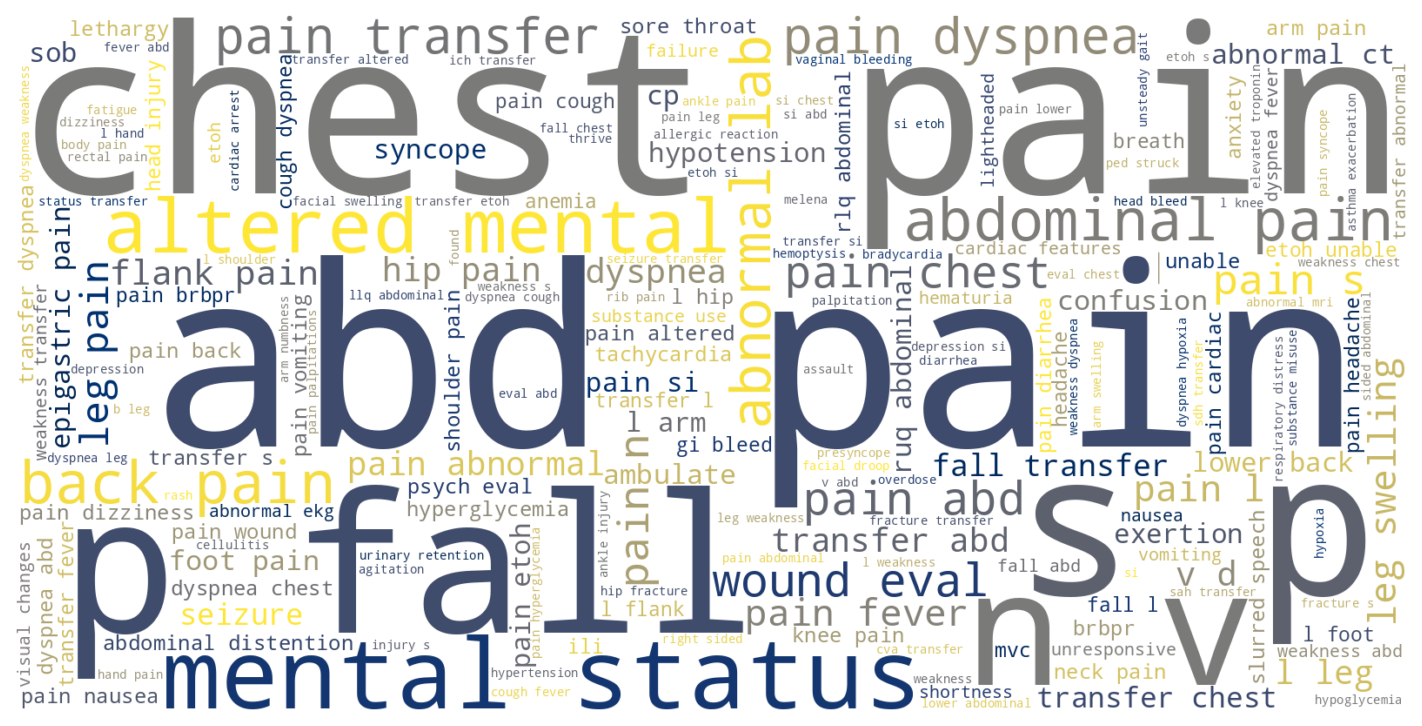

In [516]:
text = " ".join(df['chiefcomplaint'].astype(str))

wc = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    max_words=200,
    colormap='cividis'
).generate(text)


plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
print("Chief Complaint Word Cloud")

plt.tight_layout()

base_name = "wordcloud"
pdf_path = os.path.join(out_dir, f"{base_name}.pdf")
plt.savefig(pdf_path, bbox_inches="tight", pad_inches=0.02)

plt.show()
plt.close()

### **`gender`**

In [517]:
genders = df['gender'].value_counts().sort_index()

In [518]:
df['gender'] = df['gender'].map({'M': 0, 'F': 1})

In [519]:
print(df['gender'].value_counts().sort_index())

gender
0    100650
1    102340
Name: count, dtype: int64


Gender Distribution


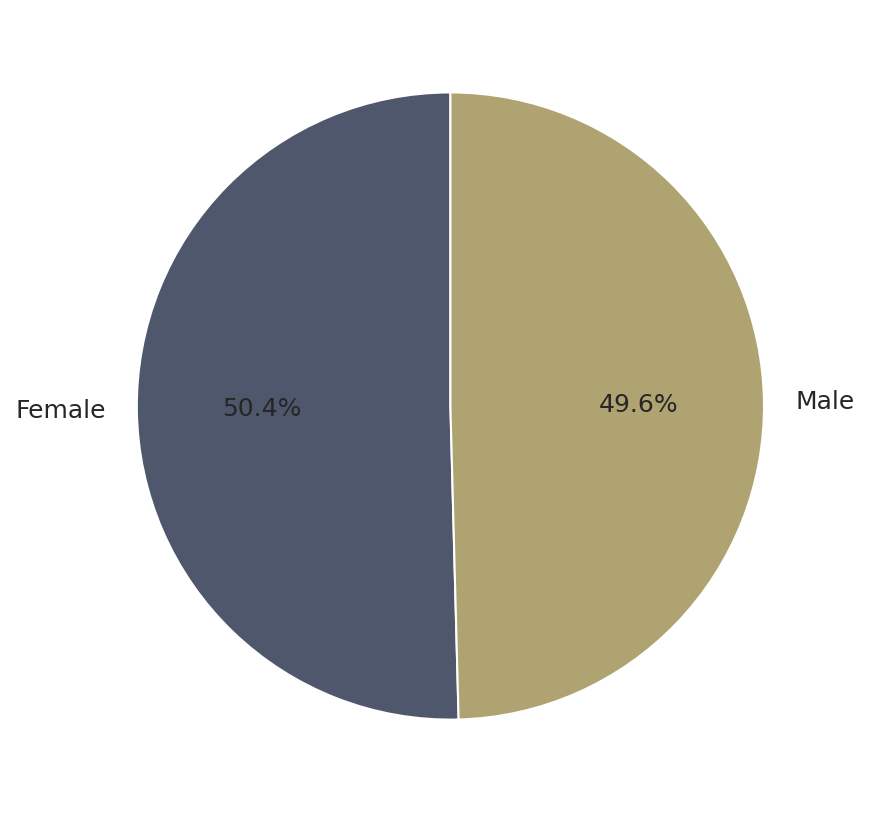

In [520]:
fig, ax = plt.subplots(figsize=(6, 6))
colors = plt.cm.cividis([0.3, 0.7])

ax.pie(
    genders,
    labels=['Female', 'Male'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

print("Gender Distribution")

plt.tight_layout()
pdf_path = os.path.join(out_dir, "gender_distribution.pdf")
fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.02)

plt.show()
plt.close(fig)

### **`age`**

Age Distribution

In [521]:
age = df['age']

print(f"Min: {age.min()}")
print(f"Max: {age.max()}")
print(f"Mean: {age.mean():.2f}")
print(f"Median: {age.median():.2f}")
print(f"Std Dev: {age.std():.2f}")
print(f"25th Percentile: {np.percentile(age, 25)}")
print(f"75th Percentile: {np.percentile(age, 75)}")

Min: 18
Max: 103
Mean: 59.99
Median: 61.00
Std Dev: 19.54
25th Percentile: 47.0
75th Percentile: 75.0


Age Distribution of Patients


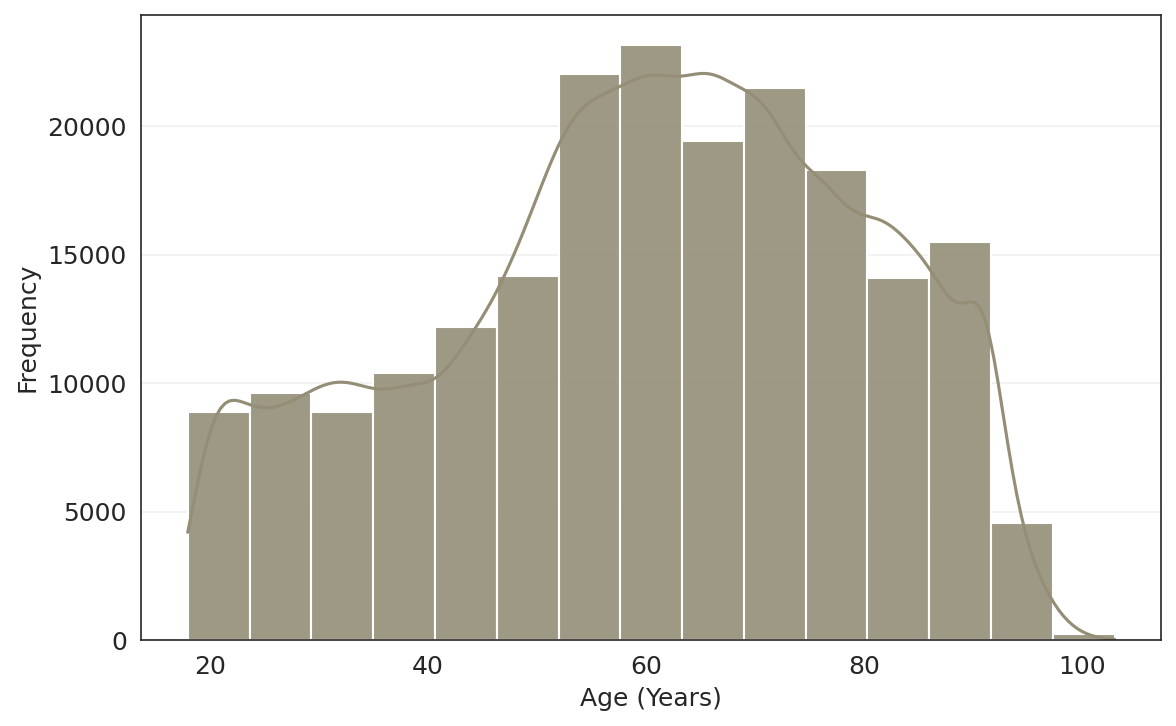

In [522]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    df['age'],
    kde=True,
    ax=ax,
    color=plt.cm.cividis(0.6),
    edgecolor=None,
    alpha=0.9,
    bins=15
)

print("Age Distribution of Patients")
ax.set_xlabel("Age (Years)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

pdf_path = os.path.join(out_dir, f"age_distribution.pdf")

fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.02)

plt.show()
plt.close(fig)

### **`temperature`**

Temperature Distribution (°F)

In [523]:
temperature = df['temperature']

print(f"Min: {temperature.min()}")
print(f"Max: {temperature.max()}")
print(f"Mean: {temperature.mean():.2f}")

Min: 80.0
Max: 107.7
Mean: 98.15



**Physiologically Plausible body temperature (°F):**

| Category               | Range        |
| ---------------------- | ------------ |
| Severe hypothermia     | < 90°F       |
| Normal                 | 96 – 100.4°F |
| Fever                  | >100.4°F     |
| Extreme survival limit | ~80 – 110°F  |


---
**80°F ≤ temperature ≤ 110°F**

### **`heartrate`**

Heart Rate Distribution (bpm)

In [524]:
heartrate = df['heartrate']

print(f"Min: {heartrate.min()}")
print(f"Max: {heartrate.max()}")
print(f"Mean: {heartrate.mean():.2f}")

Min: 20.0
Max: 230.0
Mean: 86.32


**Physiologically Plausible Heart Rate**

| Category                 | Range (bpm) |
|--------------------------|------------|
| Severe bradycardia       | < 40       |
| Bradycardia              | 40 – 60    |
| Normal                   | 60 – 100   |
| Tachycardia              | > 100      |

---

**Physiological Plausibility Range**

**30 ≤ Heart Rate ≤ 220 bpm**


### **`resprate`**

Respiratory Rate Distribution (breaths/min)

In [525]:
resprate = df['resprate']

print(f"Min: {resprate.min()}")
print(f"Max: {resprate.max()}")
print(f"Mean: {resprate.mean():.2f}")

Min: 6.0
Max: 60.0
Mean: 17.86


**Physiologically Plausible Respiratory Rate**

| Category               | Range (breaths/min) |
| ---------------------- | ------------------- |
| Severe bradypnea       | <8                  |
| Normal                 | 12–20               |
| Tachypnea              | >20                 |
| Extreme survival range | ~5–60               |


---
**5 ≤ resprate ≤ 60**

### **`o2sat`**

O2 Saturation Distribution (%)

**Physiologically Plausible Oxygen Saturation**

| Category         | Range  |
| ---------------- | ------ |
| Critical hypoxia | <70    |
| Hypoxia          | 70–89  |
| Normal           | 90–100 |

---
50 ≤ o2sat ≤ 100

### **`sbp`**

Systolic Blood Pressure Distribution (mmHg)

In [526]:
sbp = df['sbp']

print(f"Min: {sbp.min()}")
print(f"Max: {sbp.max()}")
print(f"Mean: {sbp.mean():.2f}")

Min: 50.0
Max: 250.0
Mean: 134.50


**Physiologically Plausible SBP (Systolic Blood Pressure)**

| Category                 | SBP (mmHg) |
|--------------------------|-----------|
| Severe hypotension       | < 70      |
| Hypotension              | 70 – 90   |
| Normal                   | 90 – 120  |
| Elevated / Prehypertension | 120 – 140 |
| Hypertension             | > 140     |

---

**Physiological Plausibility Range**

**60 ≤ SBP ≤ 250 mmHg**

### **`dbp`**

Diastolic Blood Pressure Distribution (mmHg

**Physiologically Plausible DBP (Diastolic Blood Pressure)**

| Category                   | DBP (mmHg) |
|----------------------------|-----------|
| Severe hypotension         | < 40      |
| Hypotension                | 40 – 60   |
| Normal                     | 60 – 80   |
| Elevated                   | 80 – 90   |
| Hypertension               | > 90      |

---

**Physiological Plausibility Range**

**30 ≤ DBP ≤ 150 mmHg**

In [527]:
dbp = df['dbp']

print(f"Min: {dbp.min()}")
print(f"Max: {dbp.max()}")
print(f"Mean: {dbp.mean():.2f}")

Min: 30.0
Max: 150.0
Mean: 75.94


### **Shock Index**

Shock Index = Heart Rate / SBP

It is more useful as a physiological instability indicator, especially for cases like overdose, intoxication, or acute distress.

However, including it is still methodologically sound because:
1. It is widely used in **ED triage research**.
2. It captures **interaction between heart rate and systolic blood pressure**.
3. It introduces a **nonlinear clinical signal** that simple models may miss.

In [528]:
df['shock_index'] = df['heartrate'] / df['sbp']

In [529]:
shock_index = df['shock_index']

print(f"Min: {shock_index.min()}")
print(f"Max: {shock_index.max()}")
print(f"Mean: {shock_index.mean():.2f}")

Min: 0.1360544217687075
Max: 2.875
Mean: 0.66


**Physiologically Plausible Shock Index Range**

| Shock Index | Interpretation                       |
|-------------|--------------------------------------|
| < 0.5       | Low (possible bradycardia/high SBP)  |
| 0.5 – 0.7   | Normal                               |
| 0.7 – 0.9   | Elevated                             |
| ≥ 0.9       | Possible physiological instability   |
| ≥ 1.0       | Severe instability                  |

---

**Physiological Plausibility Range**

**0.3 – 2.0**

---

**Example**

| HR  | SBP | Shock Index |
|-----|-----|-------------|
| 80  | 120 | 0.67        |
| 110 | 100 | 1.10        |

The second patient shows hemodynamic stress.

### **Pulse Pressure**

pulse_pressure = sbp - dbp

In [530]:
df['pulse_pressure'] = df['sbp'] - df['dbp']

In [531]:
pulse_pressure = df['pulse_pressure']

print(f"Min: {pulse_pressure.min()}")
print(f"Max: {pulse_pressure.max()}")
print(f"Mean: {pulse_pressure.mean():.2f}")

Min: -26.0
Max: 190.0
Mean: 58.56


**Physiologically Plausible Pulse Pressure Range**

| Pulse Pressure (mmHg) | Interpretation                             |
|------------------------|------------------------------------------|
| < 30                   | Low (possible poor cardiac output)       |
| 30 – 50                | Normal                                   |
| 50 – 60                | Slightly elevated                        |
| > 60                   | High (arterial stiffness / CV stress)    |

---

**Physiological Plausibility Range**

**10 ≤ Pulse Pressure ≤ 120 mmHg**

### **`acuity`**

| Acuity | Meaning                                    |
| ------ | ------------------------------------------ |
| **1**  | Immediate life-threatening (resuscitation) |
| **2**  | High risk / very urgent                    |
| **3**  | Urgent but stable                          |
| **4**  | Less urgent                                |
| **5**  | Non-urgent                                 |


In [532]:
print(df['acuity'].value_counts().sort_index())

acuity
1.0     18950
2.0    101554
3.0     81099
4.0      1349
5.0        38
Name: count, dtype: int64


### **Final Check**

In [533]:
binary_cols = [
    "flag_direct_srb",
    "flag_overdose_or_poisoning",
    "flag_mood_disturbance",
    "flag_anxiety_distress",
    "flag_psychosis",
    "flag_behavioral_dysregulation",
    "flag_substance_related",
    "flag_sleep_disturbance",

    "prior_90d_ssri_prescription",
    "prior_90d_snri_prescription",
    "prior_90d_antipsychotic_prescription",
    "prior_90d_mood_stabilizer_prescription",

    "hist_sud",
    "hist_mood",
    "hist_anxiety",
    "hist_srb",
    "hist_ptsd",
    "hist_psychotic_disorder",
    "hist_chronic_pain",
    "hist_cancer",

    "is_night_admission",
    "is_weekend_admission",

    "srb_outcome"
]

for col in binary_cols:
    df[col] = df[col].astype(int)

### **`srb_outcome`**          

In [534]:
print(df['srb_outcome'].value_counts().sort_index())

srb_outcome
0    199604
1      3386
Name: count, dtype: int64


SRB Outcome Distribution


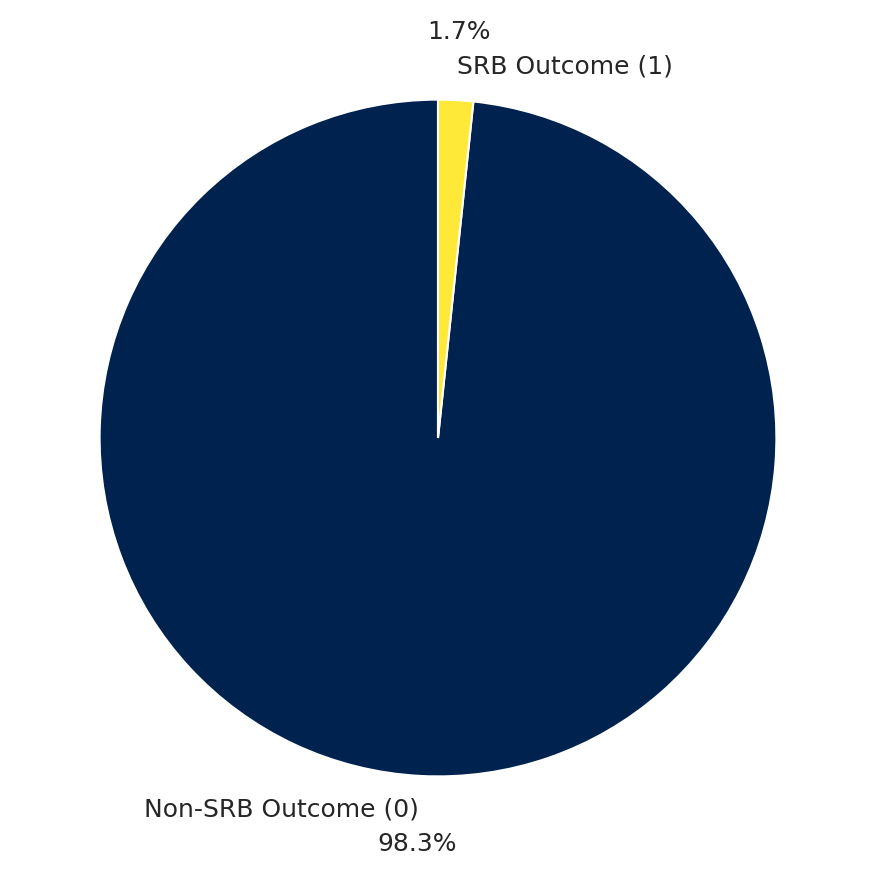

In [535]:
fig, ax = plt.subplots(figsize=(6, 6))

counts = df['srb_outcome'].value_counts().sort_index()
num_classes = len(counts)
colors = plt.cm.cividis(np.linspace(0, 1, num_classes))

ax.pie(
    counts,
    labels=['Non-SRB Outcome (0)', 'SRB Outcome (1)'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=1.2,
    labeldistance=1.1
)

print("SRB Outcome Distribution")
plt.tight_layout()

pdf_path = os.path.join(out_dir, "srb_outcome.pdf")
fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.02)

plt.show()
plt.close(fig)

In [536]:
targets = ['srb_outcome']

cols = [col for col in df.columns if col not in targets] + targets

df = df[cols]

In [537]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202990 entries, 0 to 202989
Data columns (total 57 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   subject_id                              202990 non-null  int64  
 1   hadm_id                                 202990 non-null  int64  
 2   stay_id                                 202990 non-null  int64  
 3   triage_time                             202990 non-null  object 
 4   chiefcomplaint                          202990 non-null  object 
 5   gender                                  202990 non-null  int64  
 6   age                                     202990 non-null  int64  
 7   temperature                             202990 non-null  float64
 8   heartrate                               202990 non-null  float64
 9   resprate                                202990 non-null  float64
 10  o2sat                                   2029

### **Download data**

In [538]:
df.to_csv("final_proc_data.csv", index=False)
files.download("final_proc_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>